#  Analyse Exploratoire des Données (EDA)

## Contexte Business
Nous travaillons pour une entreprise SaaS avec 10 000 clients. L'objectif est de construire un système intelligent de rétention client capable d'anticiper les résiliations et d'évaluer l'impact financier.

## Nos 2 Problématiques

### Problématique 1 — Classification (obligatoire)
**Question :** Quel client va résilier son abonnement ?
**Variable cible :** `churn` (0 = reste, 1 = part)
**Intérêt business :** Prioriser les actions de rétention marketing

### Problématique 2 — Régression (points bonus)
**Question :** Combien d'argent risque-t-on de perdre ?
**Variable cible :** `revenue_at_risk = total_revenue × churn`
**Intérêt business :** Prioriser les clients à forte valeur financière

## Questions auxquelles l'EDA va répondre
1. Qui sont les clients qui churnent ?
2. Quels comportements annoncent un départ ?
3. Quelles variables sont les plus corrélées au churn ?
4. Quels segments sont les plus à risque financièrement ?
5. Y a-t-il des valeurs manquantes ou des outliers à traiter ?

---
## PARTIE 1 — Exploration générale des données
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/customer_churn_business_dataset.csv')

## Premier regard sur les données

On affiche 10 lignes aléatoires du dataset.

Objectif : vérifier que les données sont bien chargées et 
comprendre la structure du tableau :

- Quelles colonnes existent ?
- Quels types de valeurs ?
- On remarque déjà que `complaint_type` a des valeurs `NaN`

In [2]:
df.sample(10)

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
749,CUST_00750,Female,61,Australia,Sydney,SME,32,Web,Quarterly,15,...,25.387720,Billing,5.0,0,0.27,0.21,60,Unsatisfied,1,1
1870,CUST_01871,Male,32,Canada,London,Individual,23,Mobile,Quarterly,26,...,36.548524,Billing,3.0,0,0.65,0.16,25,Satisfied,0,0
44,CUST_00045,Female,29,Bangladesh,Dhaka,Individual,41,Referral,Monthly,5,...,42.107836,Billing,4.0,0,0.56,0.08,9,Unsatisfied,5,0
5996,CUST_05997,Male,47,Germany,London,Individual,57,Web,Quarterly,17,...,19.597293,Billing,5.0,0,0.58,0.07,69,Satisfied,1,0
9045,CUST_09046,Female,44,UK,New York,Individual,47,Mobile,Monthly,32,...,28.808783,Technical,3.0,0,0.23,0.04,69,Satisfied,2,0
2185,CUST_02186,Male,74,Bangladesh,Sydney,SME,14,Web,Monthly,37,...,28.630356,Technical,2.0,0,0.81,0.28,100,Satisfied,2,0
9595,CUST_09596,Female,29,Bangladesh,Sydney,Individual,28,Web,Monthly,36,...,25.896027,Technical,4.0,0,0.78,0.32,-7,Unsatisfied,1,0
7859,CUST_07860,Male,46,UK,New York,SME,28,Web,Monthly,30,...,33.378346,Service,4.0,0,0.84,0.29,27,Satisfied,0,0
2769,CUST_02770,Male,45,USA,New York,Individual,41,Mobile,Yearly,6,...,18.917480,Billing,3.0,0,0.74,0.30,61,Satisfied,1,0
4883,CUST_04884,Male,48,India,Sydney,Individual,2,Mobile,Monthly,12,...,29.428968,Service,4.0,1,0.19,0.01,-19,Neutral,2,0


## Dimensions du dataset

On retourne un tuple (lignes, colonnes) :
- **10 000 lignes** = 10 000 clients
- **32 colonnes** = 32 variables par client

C'est un dataset de taille moyenne, suffisant pour entraîner 
des modèles de Machine Learning fiables.

In [3]:
print(f"Nombre de ligne : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de ligne : 10000
Nombre de colonnes : 32


## Types des colonnes

On affiche le type de chaque colonne :
- **int64** = nombre entier (ex: age, churn)
- **float64** = nombre décimal (ex: monthly_fee, nps_score)
- **object** = texte / catégorie (ex: gender, country)

Cette étape est importante car les modèles de Machine Learning ne comprennent que des chiffres. Les colonnes "object" devront être converties en chiffres lors du preprocessing.

In [4]:
df.dtypes

customer_id                object
gender                     object
age                         int64
country                    object
city                       object
customer_segment           object
tenure_months               int64
signup_channel             object
contract_type              object
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method             object
payment_failures            int64
discount_applied           object
price_increase_last_3m     object
support_tickets             int64
avg_resolution_time       float64
complaint_type             object
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_rate      float64
nps_score                   int64
survey_respons

## Vérification des doublons

**Résultat : 0 doublon** 
Les données sont propres sur ce point, rien à supprimer.

In [5]:
df.duplicated().sum()

np.int64(0)

## Valeurs manquantes

`df.isnull().sum()` compte le nombre de valeurs vides par colonne.

**Résultat :**
- Toutes les colonnes : 0 valeur manquante 
- **complaint_type : 2045 valeurs manquantes** 

Pourquoi complaint_type a des manquants ?
Logique métier : un client qui n'a jamais fait de plainte n'a pas de type de plainte. Ce n'est pas une erreur,  c'est une information en soi.

**Décision :** On remplacera ces manquants par "No_Complaint" lors du preprocessing.

In [6]:
df.isnull().sum()

customer_id                  0
gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                        0
dtype: i

## Statistiques descriptives

On affiche pour chaque colonne numérique :
- **count** : nombre de valeurs
- **mean** : moyenne
- **std** : écart-type (dispersion des valeurs)
- **min / max** : valeurs minimale et maximale
- **25%, 50%, 75%** : quartiles

Points importants observés :
- `churn` : moyenne = 0.102 → seulement 10.2% de churners 
- `nps_score` (C'est une mesure de satisfaction client) : va de -100 à +100 (valeurs négatives normales)
- `total_revenue` : très étalé de 10€ à 5900€
- `last_login_days_ago` : max = 80 jours (clients très inactifs)

In [7]:
df.describe()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


## Colonnes catégorielles

On identifie les 12 colonnes de type texte (object). Ce sont ces colonnes qu'on devra encoder en chiffres lors du preprocessing car le Machine Learning ne comprend que des nombres.

In [8]:
df.select_dtypes(include='object').columns.tolist()

['customer_id',
 'gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response']

---
## PARTIE 2 — Analyses spécifiques à la Classification
---

## Distribution de la variable cible — Churn

On analyse la répartition de notre variable cible `churn` :
- **8 979 clients restent** (89.8%)
- **1 021 clients partent** (10.2%)

Le dataset est très déséquilibré !

Problème : Un modèle qui prédit "le client reste" pour TOUS les clients aurait 89.8% d'accuracy, 
même s'il n'apprend rien.

Solution : on utilisera `class_weight='balanced'` dans nos modèles pour forcer le modèle à accorder plus d'importance aux churners.

On privilégiera aussi des métriques adaptées :
- **Recall** : détecte-t-on bien les churners ?
- **F1-Score** : équilibre entre precision et recall
- **ROC-AUC** : performance globale du modèle

In [9]:
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print("Distribution du Churn :")
print(f"  Clients qui restent  (0) : {churn_counts[0]} ({churn_pct[0]:.1f}%)")
print(f"  Clients qui partent  (1) : {churn_counts[1]} ({churn_pct[1]:.1f}%)")

Distribution du Churn :
  Clients qui restent  (0) : 8979 (89.8%)
  Clients qui partent  (1) : 1021 (10.2%)


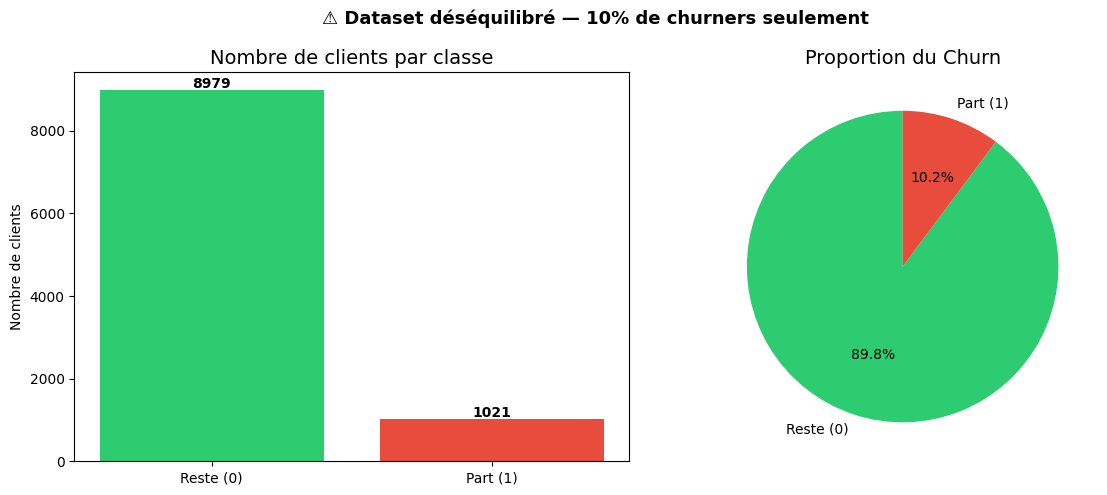

In [10]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1 — Barplot
axes[0].bar(['Reste (0)', 'Part (1)'], 
            churn_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Nombre de clients par classe', fontsize=14)
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Graphique 2 — Camembert
axes[1].pie(churn_counts.values,
            labels=['Reste (0)', 'Part (1)'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Proportion du Churn', fontsize=14)

plt.suptitle('⚠️ Dataset déséquilibré — 10% de churners seulement', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Analyse du Revenu à Risque

Maintenant qu'on sait que 10.2% des clients churnent, on cherche à quantifier l'impact financier pour l'entreprise.

**Résultats :**
- Revenu moyen des clients qui **restent** : **1 081€**
- Revenu moyen des clients qui **partent** : **845€**
- Revenu total à risque : **862 640€**

Les churners ont un revenu moyen plus faible que les non-churners — ce sont souvent des clients récents (tenure faible) avec des abonnements moins élevés.

**Implication** : même si le revenu moyen par churner est plus faible, la masse de 862 640€ justifie pleinement la Problématique 2 (régression).

In [11]:

# ANALYSE DU REVENU À RISQUE

# Revenu moyen par groupe churn

# Divise le dataset en 2 groupes, Groupe 0 : clients qui restent, Groupe 1 : clients qui partent,
revenu_par_churn = df.groupby('churn')['total_revenue'].mean() 

print(" Revenu moyen :")
print(f"  Clients qui restent  (0) : {revenu_par_churn[0]:.0f}€") #Accède à la moyenne des churn=0
print(f"  Clients qui partent  (1) : {revenu_par_churn[1]:.0f}€") #Accède à la moyenne des churn=1


# Revenu total à risque estimé
revenu_total_risque = df[df['churn'] == 1]['total_revenue'].sum()
print(f"\n Revenu total à risque : {revenu_total_risque:,}€")
#Formate le nombre :.0f = 0 décimales Exemple : 1083.456 → 1083

 Revenu moyen :
  Clients qui restent  (0) : 1081€
  Clients qui partent  (1) : 845€

 Revenu total à risque : 862,640€


## Taux de churn par variable catégorielle

On calcule le taux de churn moyen pour chaque modalité. La ligne pointillée = moyenne globale (10.2%).

Insights majeurs :
- `customer_segment` SME : **30.9% de churn** 
  Les petites entreprises sont 3x plus à risque que les particuliers
- `signup_channel` Mobile : **30%** 
  Les clients acquis via mobile partent beaucoup plus
- `price_increase_last_3m` Yes : **30.4%** 
  Une hausse de prix récente = signal fort de départ
- `country` Australia : **11.5%** légèrement au-dessus
- `survey_response` Unsatisfied : **11.1%** légèrement au-dessus

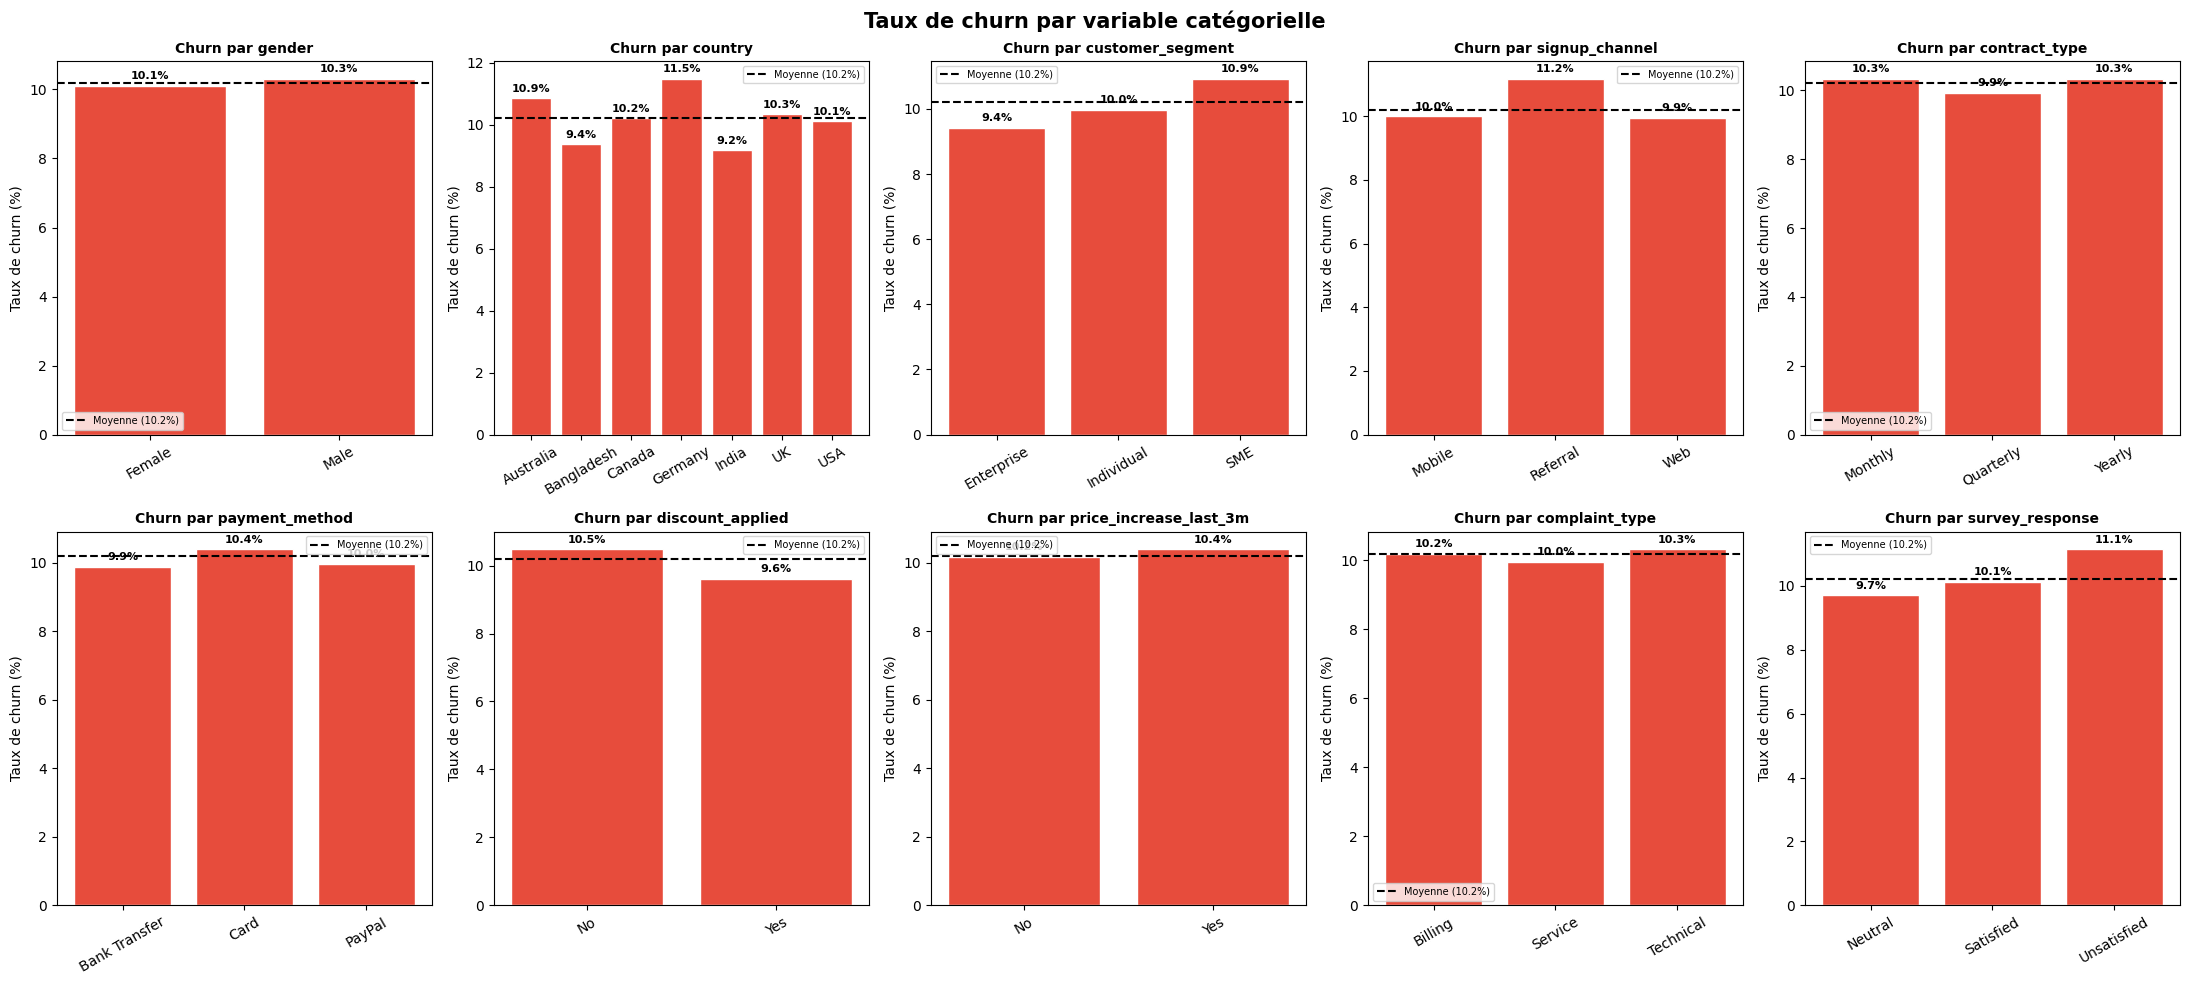

In [14]:
# CHURN PAR VARIABLE CATÉGORIELLE

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    # Taux de churn moyen par catégorie
    churn_rate = df.groupby(col)['churn'].mean() * 100
    
    bars = axes[i].bar(churn_rate.index, 
                       churn_rate.values,
                       color='#e74c3c', 
                       edgecolor='white')
    axes[i].set_title(f'Churn par {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Taux de churn (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=10.2, color='black', linestyle='--', 
                    label='Moyenne (10.2%)')
    axes[i].legend(fontsize=7)
    
    # Afficher les % sur les barres
    for j, v in enumerate(churn_rate.values):
        axes[i].text(j, v + 0.2, f'{v:.1f}%', 
                    ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Taux de churn par variable catégorielle', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Distribution des variables numériques selon le churn

On superpose les distributions des clients qui restent (vert) 
et des clients qui partent (rouge) pour chaque variable.

Insights clés :
- `tenure_months` : les churners sont concentrés au début (0-5 mois)
  → Les nouveaux clients partent plus facilement
- `payment_failures` : les churners ont plus d'échecs de paiement
  → Signal fort de risque de churn
- `support_tickets` : les churners ouvrent plus de tickets
  → La frustration mène au départ
- `nps_score` : les churners ont un NPS plus bas
  → Un client insatisfait est un client à risque
- `last_login_days_ago` : les churners se connectent moins
  → Le désengagement précède le départ
- `csat_score` : les churners ont un score de 2 principalement
  → Satisfaction basse = départ

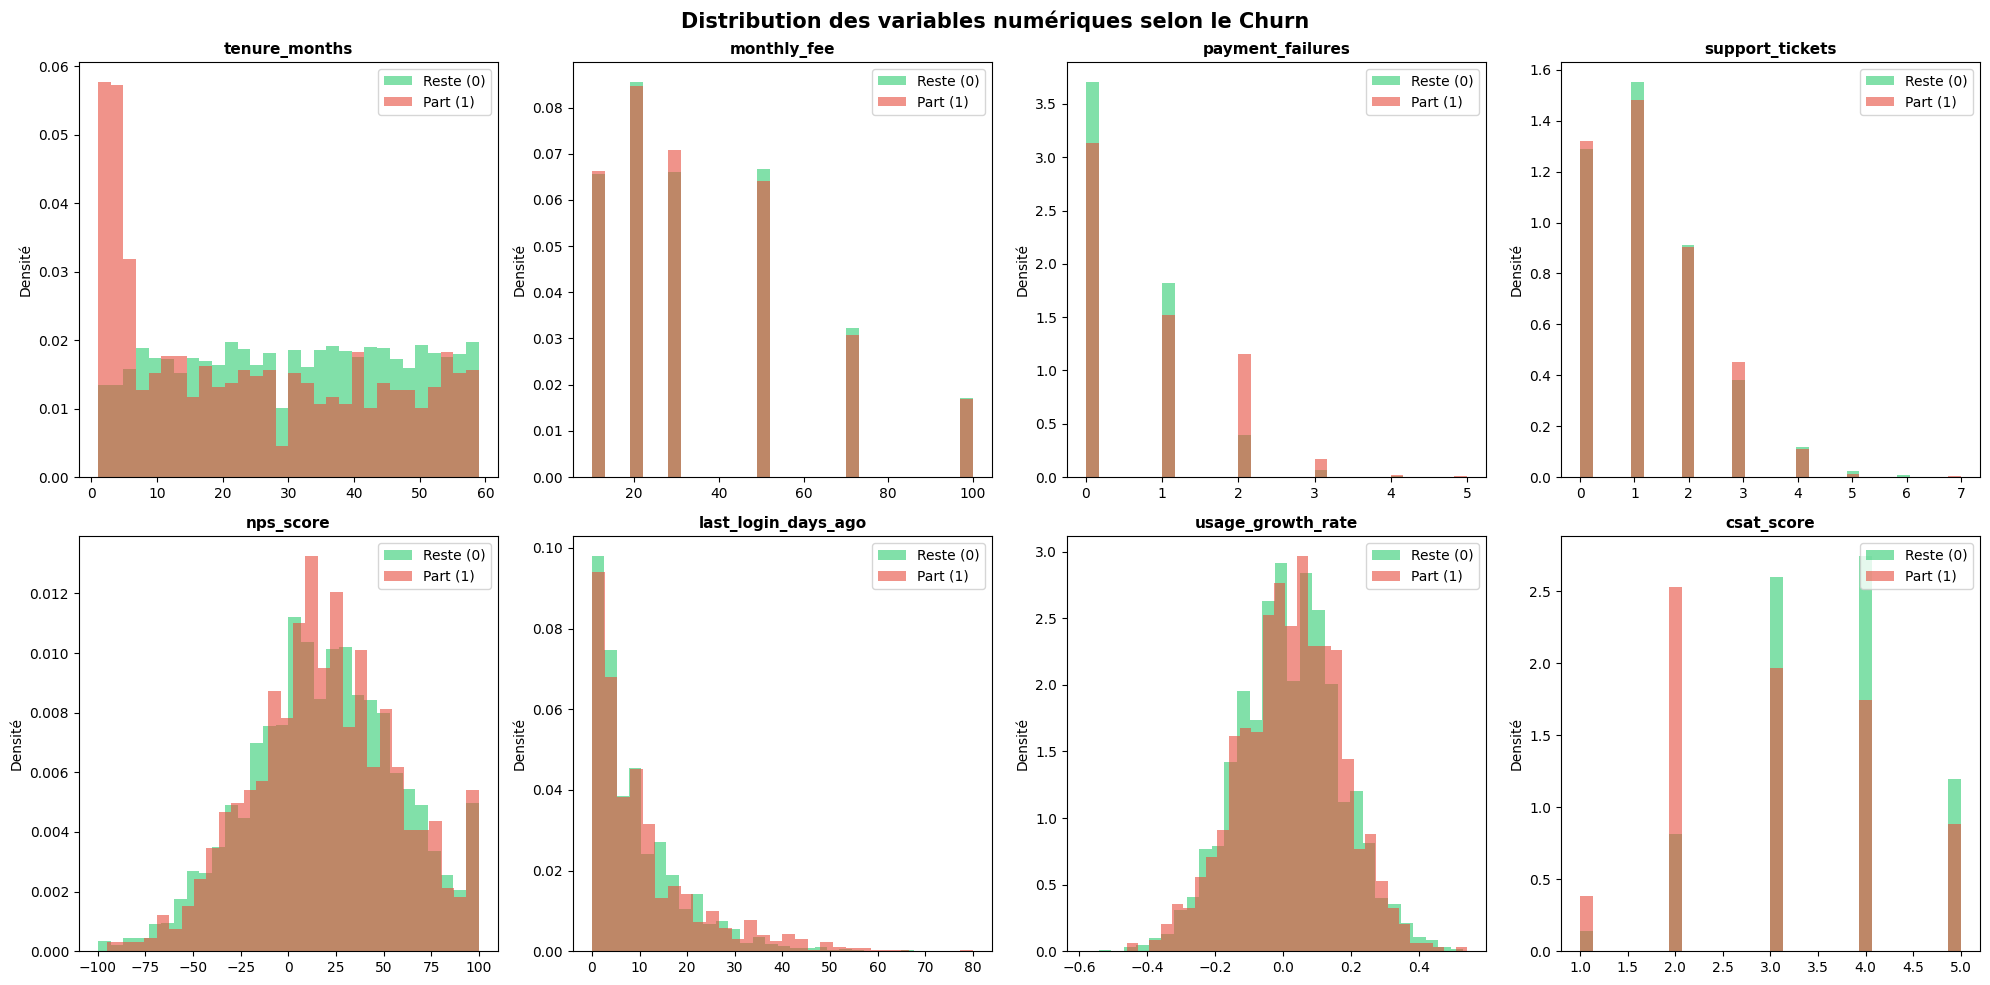

In [15]:

# CHURN PAR VARIABLE NUMÉRIQUE

cols_num_importantes = ['tenure_months', 'monthly_fee', 
                        'payment_failures', 'support_tickets',
                        'nps_score', 'last_login_days_ago',
                        'usage_growth_rate', 'csat_score']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_num_importantes):
    # Clients qui restent vs qui partent
    reste = df[df['churn'] == 0][col]
    part = df[df['churn'] == 1][col]
    
    axes[i].hist(reste, bins=30, alpha=0.6, 
                 color='#2ecc71', label='Reste (0)', density=True)
    axes[i].hist(part, bins=30, alpha=0.6, 
                 color='#e74c3c', label='Part (1)', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Densité')
    axes[i].legend()

plt.suptitle('Distribution des variables numériques selon le Churn', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Matrice de corrélation

La heatmap montre les corrélations entre toutes les variables 
numériques. Une corrélation va de -1 à +1 :
- **+1** : quand une variable augmente, l'autre aussi
- **-1** : quand une variable augmente, l'autre diminue
- **0** : aucun lien entre les deux variables

Corrélations avec le churn :
- `csat_score` : **-0.16** → satisfaction basse = plus de churn
- `tenure_months` : **-0.12** → ancienneté haute = moins de churn
- `payment_failures` : **+0.11** → échecs = plus de churn

Corrélations entre variables :
- `monthly_fee` ↔ `total_revenue` : **+0.71** 
  Ces deux variables sont très liées → attention à la redondance
- `tenure_months` ↔ `total_revenue` : **+0.59**
  Logique : plus on est ancien, plus on a payé au total

Les corrélations faibles avec le churn confirment que le Machine 
Learning est nécessaire — le churn dépend de combinaisons 
complexes de variables, pas d'une seule.

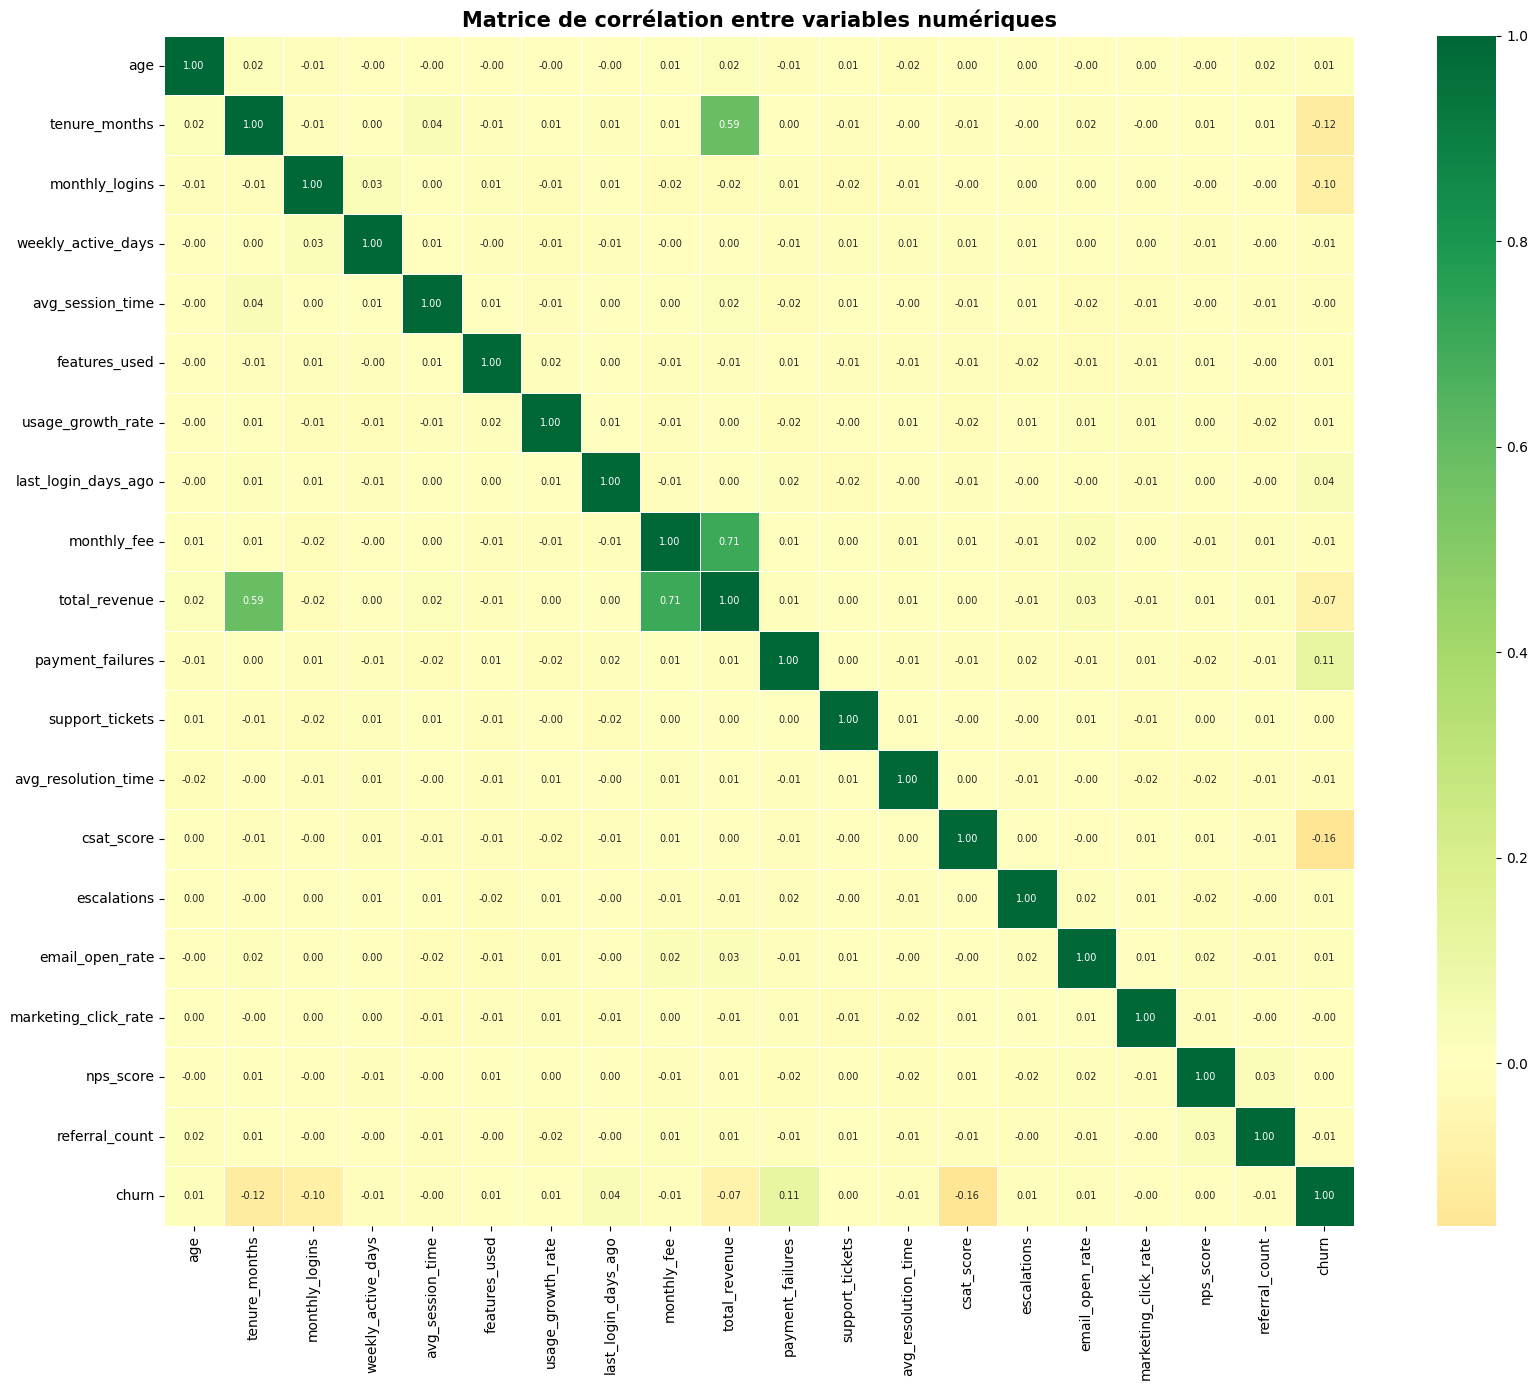

In [16]:

# HEATMAP DES CORRÉLATIONS

# Sélectionner uniquement les colonnes numériques
cols_corr = ['age', 'tenure_months', 'monthly_logins',
             'weekly_active_days', 'avg_session_time',
             'features_used', 'usage_growth_rate',
             'last_login_days_ago', 'monthly_fee',
             'total_revenue', 'payment_failures',
             'support_tickets', 'avg_resolution_time',
             'csat_score', 'escalations', 'email_open_rate',
             'marketing_click_rate', 'nps_score', 
             'referral_count', 'churn']

# Calculer la matrice de corrélation
corr_matrix = df[cols_corr].corr()

# Visualisation
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix,
            annot=True,           # afficher les valeurs
            fmt='.2f',            # 2 décimales
            cmap='RdYlGn',        # rouge = négatif, vert = positif
            center=0,             # centré sur 0
            square=True,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Matrice de corrélation entre variables numériques', 
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Détection des outliers — Boxplots

Un boxplot montre la distribution d'une variable :
- La boîte = 50% des données (entre 25% et 75%)
- La ligne noire = médiane (valeur du milieu)
- Les cercles = outliers (valeurs extrêmes)

Observations :
- `total_revenue` : outliers jusqu'à 5900€ → gros clients réels 
- `last_login_days_ago` : outliers jusqu'à 80 jours → inactifs 
- `payment_failures` : outliers à 4-5 → très mauvais payeurs 
- `nps_score` : outliers à -100 → clients très insatisfaits 
- `tenure_months` : churners ont une médiane plus basse → confirmé

**Décision : on garde tous les outliers.**
Ce ne sont pas des erreurs — ce sont des signaux business réels 
et importants pour prédire le churn.

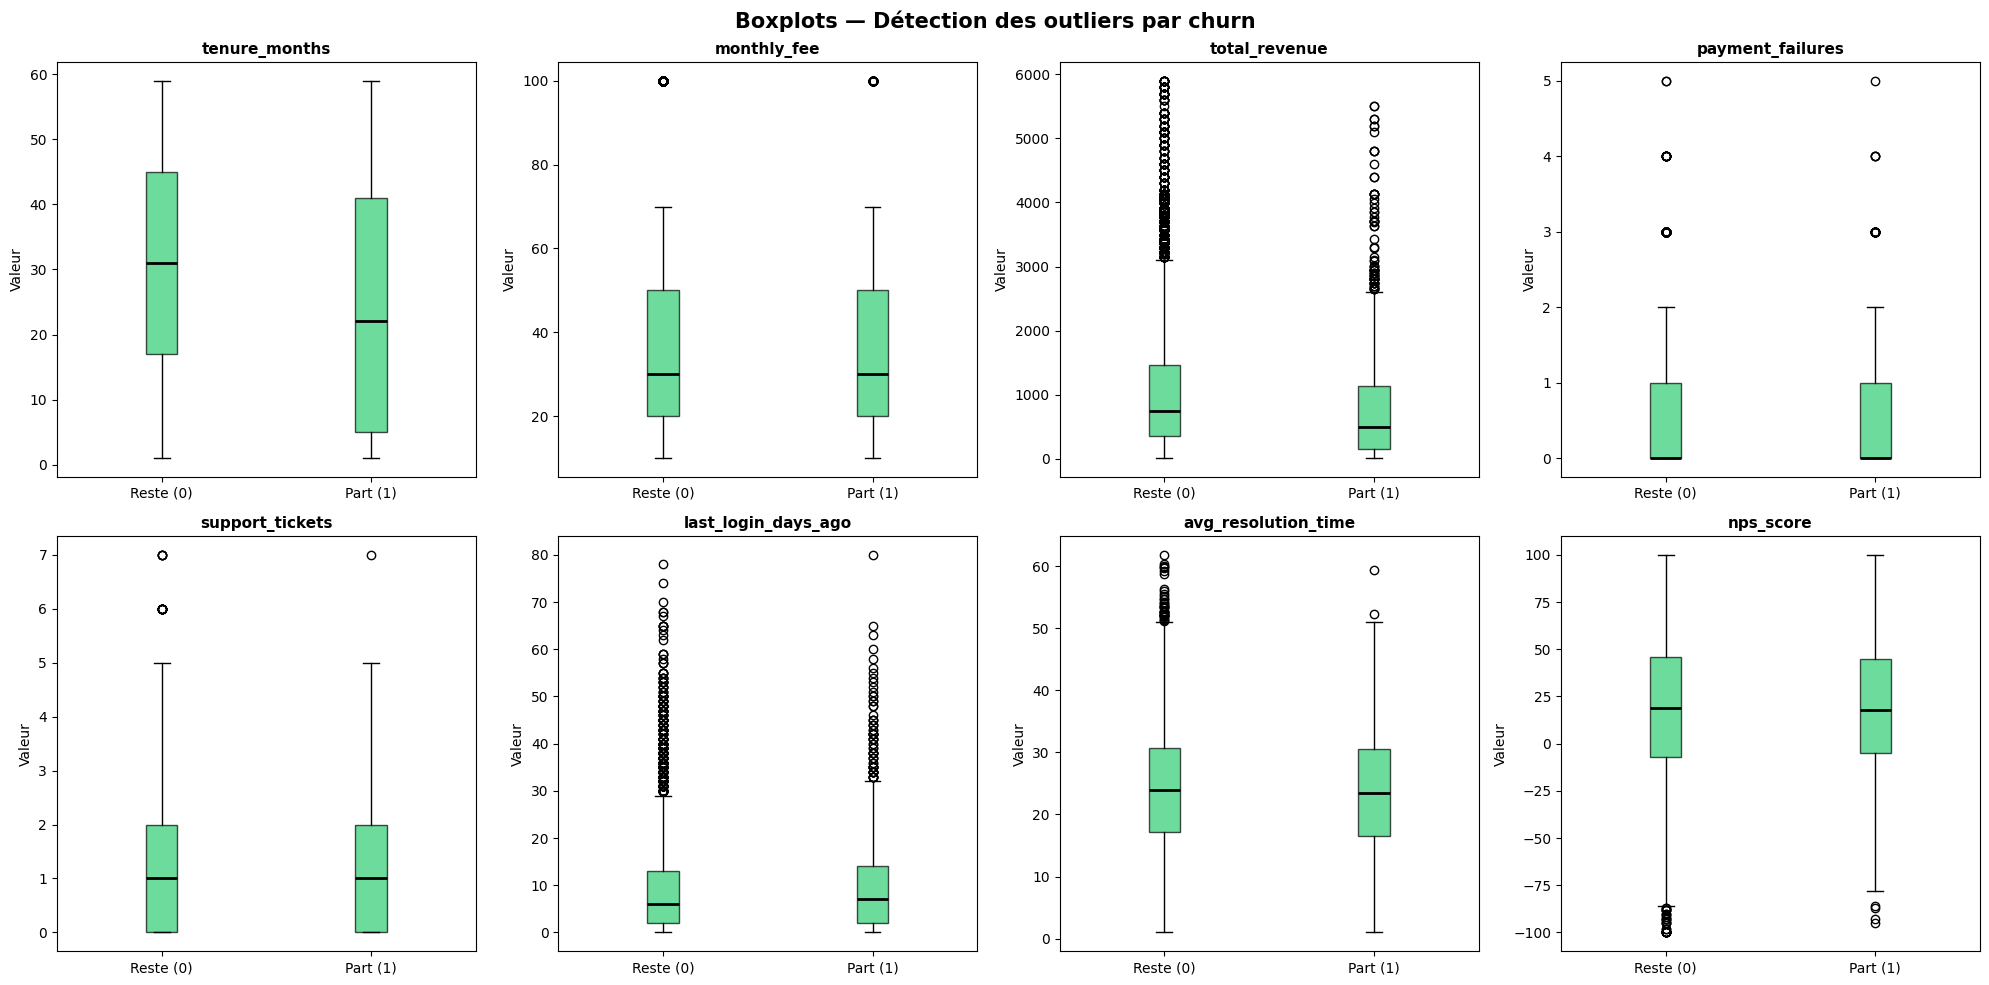

In [17]:

# DÉTECTION DES OUTLIERS
cols_outliers = ['tenure_months', 'monthly_fee', 'total_revenue',
                 'payment_failures', 'support_tickets',
                 'last_login_days_ago', 'avg_resolution_time',
                 'nps_score']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_outliers):
    data_reste = df[df['churn'] == 0][col]
    data_part = df[df['churn'] == 1][col]
    
    axes[i].boxplot([data_reste, data_part],
                    tick_labels=['Reste (0)', 'Part (1)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#2ecc71', alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Valeur')

plt.suptitle('Boxplots — Détection des outliers par churn',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()  # ← juste ça !

## Heatmap croisée — Segment client × Type de contrat

On croise deux variables clés pour identifier les **sous-segments les plus à risque**.

On calcule pour chaque combinaison (segment × contrat) le taux de churn moyen.

Insights attendus :
- Les clients **SME** ont déjà un taux de churn de 30.9% en moyenne
- Combinés à un contrat **Monthly** (sans engagement), ce taux est encore plus élevé
- Les clients **Enterprise** avec contrat **Annual** sont les plus fidèles

Ce croisement est crucial pour la classification : il révèle des profils à très haut risque que les variables prises individuellement ne montrent pas.

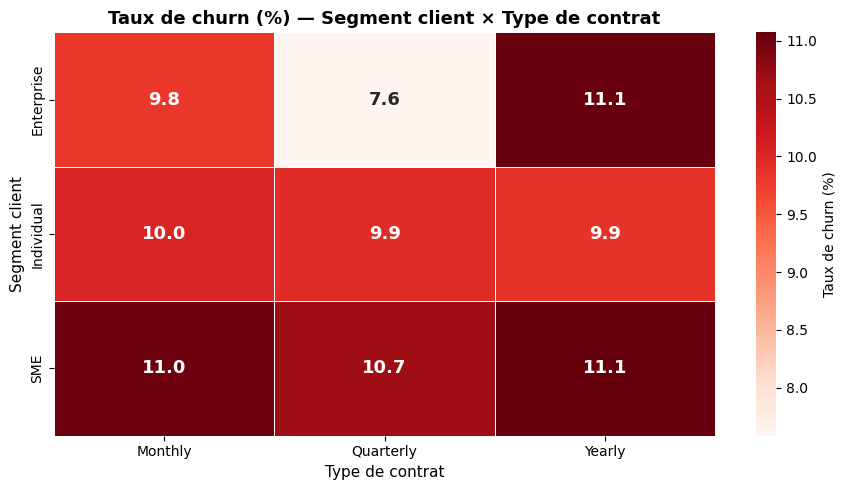

In [18]:
# HEATMAP CROISÉE — SEGMENT × CONTRAT

pivot = df.pivot_table(values='churn',
                       index='customer_segment',
                       columns='contract_type',
                       aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot,
            annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5,
            annot_kws={'size': 13, 'fontweight': 'bold'},
            ax=ax,
            cbar_kws={'label': 'Taux de churn (%)'})

ax.set_title('Taux de churn (%) — Segment client × Type de contrat',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Type de contrat', fontsize=11)
ax.set_ylabel('Segment client', fontsize=11)
plt.tight_layout()
plt.show()

---
## PARTIE 3 — Analyses spécifiques à la Régression
---

## Distribution de `revenue_at_risk` — Variable cible Régression

`revenue_at_risk` est la variable qu'on cherche à **prédire** avec le modèle de régression.

Elle est construite comme suit : `revenue_at_risk = total_revenue × churn`

Résultats observés :
- **89.8% des valeurs = 0€** : les clients qui ne churnent pas ont un risque nul
- Sur les **1 021 churners**, le revenu à risque va de quelques euros à **5 500€**
- **Moyenne : 845€**, mais **médiane : 490€** → distribution très asymétrique (skewness = 1.95)
- **Revenu total à risque : 862 640€**

La forte asymétrie (skewness = 1.95) et la masse de zéros expliquent pourquoi une régression linéaire simple serait inefficace. On privilégiera des modèles robustes comme **Random Forest** ou **XGBoost**.

C:\Users\ervin\AppData\Local\Temp\ipykernel_36692\2514296910.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ervin\Documents\efrei\data\projet-data-science\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


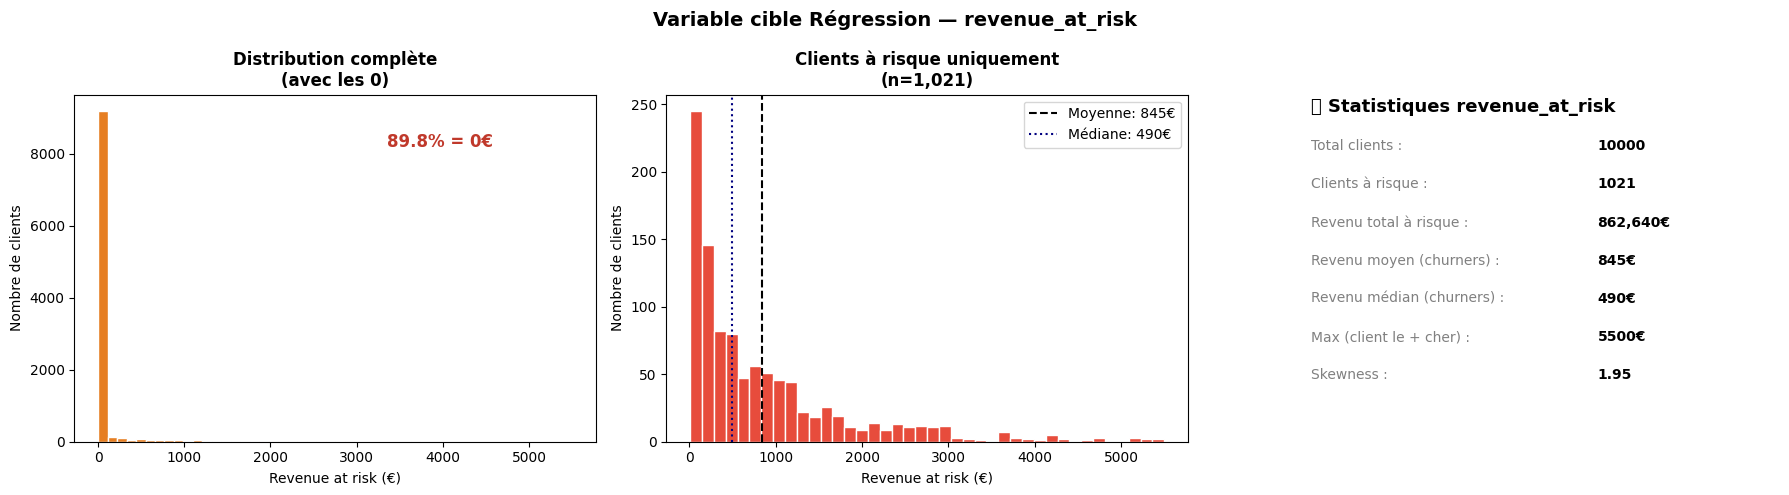

In [20]:
# DISTRIBUTION DE REVENUE_AT_RISK
df['revenue_at_risk'] = df['total_revenue'] * df['churn']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphe 1 — Distribution complète (avec les 0)
axes[0].hist(df['revenue_at_risk'], bins=50,
             color='#e67e22', edgecolor='white')
axes[0].set_title('Distribution complète\n(avec les 0)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Revenue at risk (€)')
axes[0].set_ylabel('Nombre de clients')
zero_pct = (df['revenue_at_risk'] == 0).mean() * 100
axes[0].text(0.6, 0.85, f'{zero_pct:.1f}% = 0€',
             transform=axes[0].transAxes, fontsize=12,
             fontweight='bold', color='#c0392b')

# Graphe 2 — Distribution des clients à risque uniquement (sans les 0)
risk_only = df[df['revenue_at_risk'] > 0]['revenue_at_risk']
axes[1].hist(risk_only, bins=40, color='#e74c3c', edgecolor='white')
axes[1].set_title(f'Clients à risque uniquement\n(n={len(risk_only):,})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Revenue at risk (€)')
axes[1].set_ylabel('Nombre de clients')
axes[1].axvline(risk_only.mean(), color='black', linestyle='--',
                label=f'Moyenne: {risk_only.mean():.0f}€')
axes[1].axvline(risk_only.median(), color='navy', linestyle=':',
                label=f'Médiane: {risk_only.median():.0f}€')
axes[1].legend()

# Graphe 3 — Statistiques clés
stats = {
    'Total clients': len(df),
    'Clients à risque': len(risk_only),
    'Revenu total à risque': f"{df['revenue_at_risk'].sum():,.0f}€",
    'Revenu moyen (churners)': f"{risk_only.mean():.0f}€",
    'Revenu médian (churners)': f"{risk_only.median():.0f}€",
    'Max (client le + cher)': f"{risk_only.max():.0f}€",
    'Skewness': f"{risk_only.skew():.2f}"
}
axes[2].axis('off')
y_pos = 0.95
axes[2].text(0.1, y_pos, '📊 Statistiques revenue_at_risk',
             fontsize=13, fontweight='bold', transform=axes[2].transAxes)
for key, val in stats.items():
    y_pos -= 0.11
    axes[2].text(0.1, y_pos, f'{key} :', fontsize=10,
                 transform=axes[2].transAxes, color='gray')
    axes[2].text(0.65, y_pos, str(val), fontsize=10,
                 transform=axes[2].transAxes, fontweight='bold')

plt.suptitle('Variable cible Régression — revenue_at_risk',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Scatter plots — `revenue_at_risk` vs prédicteurs clés

On visualise la relation entre `revenue_at_risk` et les variables numériques les plus importantes.

- Les **points gris** = non-churners (`revenue_at_risk` = 0)
- Les **points orange** = churners (`revenue_at_risk` > 0)

Observations :
- **`total_revenue`** : relation quasi-linéaire parfaite → `revenue_at_risk = total_revenue` pour les churners, c'est logique **par construction** (la formule est `revenue_at_risk = total_revenue × churn`). ⚠️ Cette relation révèle un **data leakage** : `total_revenue` sera donc **retirée des features** dans le preprocessing pour éviter que le modèle triche.
- **`tenure_months`** : plus un client est ancien, plus son revenu à risque est élevé → plusieurs strates visibles selon le `monthly_fee`
- **`monthly_fee`** : relation directe avec le revenu à risque → les clients à 100€/mois ont les valeurs les plus élevées
- **`csat_score`**, **`payment_failures`** : pas de relation claire avec le montant → ces variables prédisent **qui** part, pas **combien** on perd

**Conclusion** : le montant perdu dépend surtout de `monthly_fee` et `tenure_months` (sans `total_revenue`). La classification (qui part ?) dépend des variables comportementales.

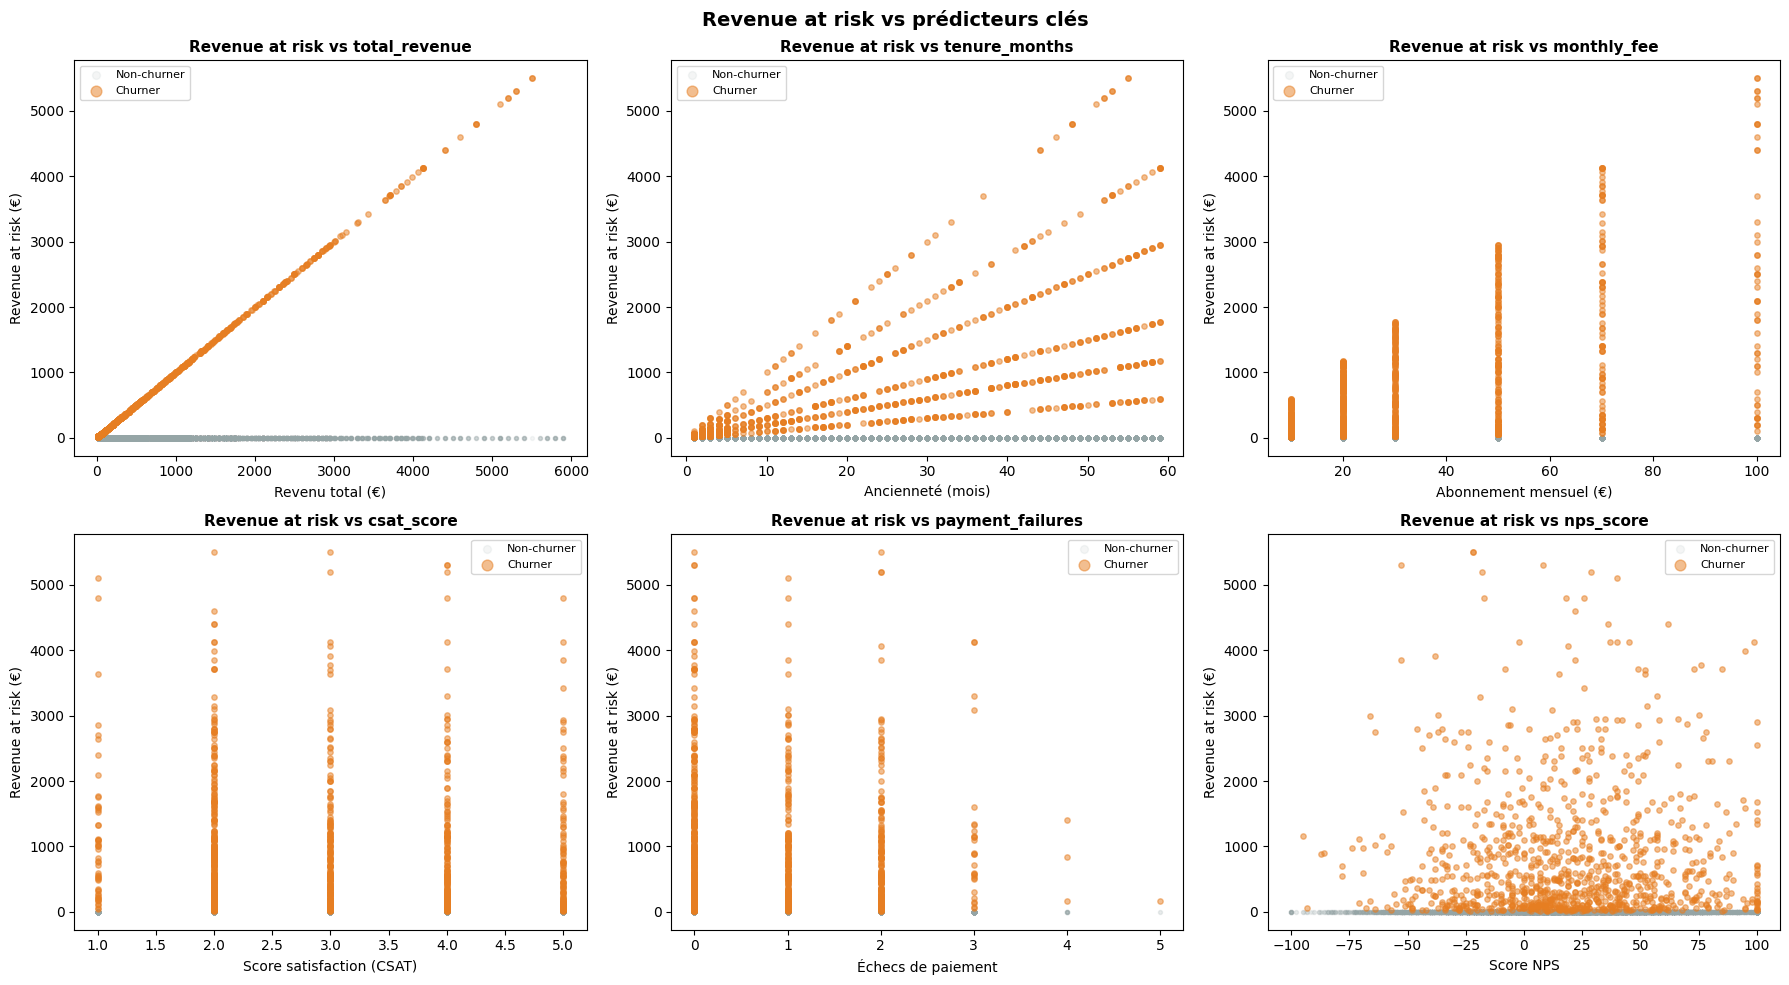

In [21]:
# SCATTER PLOTS — REVENUE_AT_RISK vs PREDICTEURS

scatter_features = [
    ('tenure_months', 'Ancienneté (mois)'),
    ('monthly_fee', 'Abonnement mensuel (€)'),
    ('csat_score', 'Score satisfaction (CSAT)'),
    ('payment_failures', 'Échecs de paiement'),
    ('nps_score', 'Score NPS')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(scatter_features):
    # Non-churners en fond
    non_churn = df[df['churn'] == 0]
    axes[i].scatter(non_churn[feat], non_churn['revenue_at_risk'],
                    alpha=0.1, color='#95a5a6', s=8, label='Non-churner')
    # Churners par-dessus
    churn_df = df[df['churn'] == 1]
    axes[i].scatter(churn_df[feat], churn_df['revenue_at_risk'],
                    alpha=0.5, color='#e67e22', s=15, label='Churner')

    axes[i].set_xlabel(label, fontsize=10)
    axes[i].set_ylabel('Revenue at risk (€)', fontsize=10)
    axes[i].set_title(f'Revenue at risk vs {feat}',
                      fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8, markerscale=2)

plt.suptitle('Revenue at risk vs prédicteurs clés',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Analyse des churners par valeur financière

Tous les churners ne représentent pas le même risque financier. On les segmente en 3 tiers selon leur `revenue_at_risk` :

- **High value** (> 1140€) : les clients dont le départ coûte le plus cher
- **Medium value** (entre 150€ et 1140€) : la majorité des churners
- **Low value** (< 150€) : churners à faible impact financier

Résultats :
- Les **515 clients High Value** concentrent **573 520€** sur 862 640€ total → soit **66% du risque** pour 50% des churners
- Les clients Low Value ne représentent que **16 610€** → priorité de rétention faible
- Le profil High Value : clients anciens avec un abonnement élevé → clients fidèles et à forte valeur

**Implication business** : le modèle de régression permet de prioriser les actions de rétention sur les 515 clients High Value plutôt que de traiter tous les churners de la même façon.

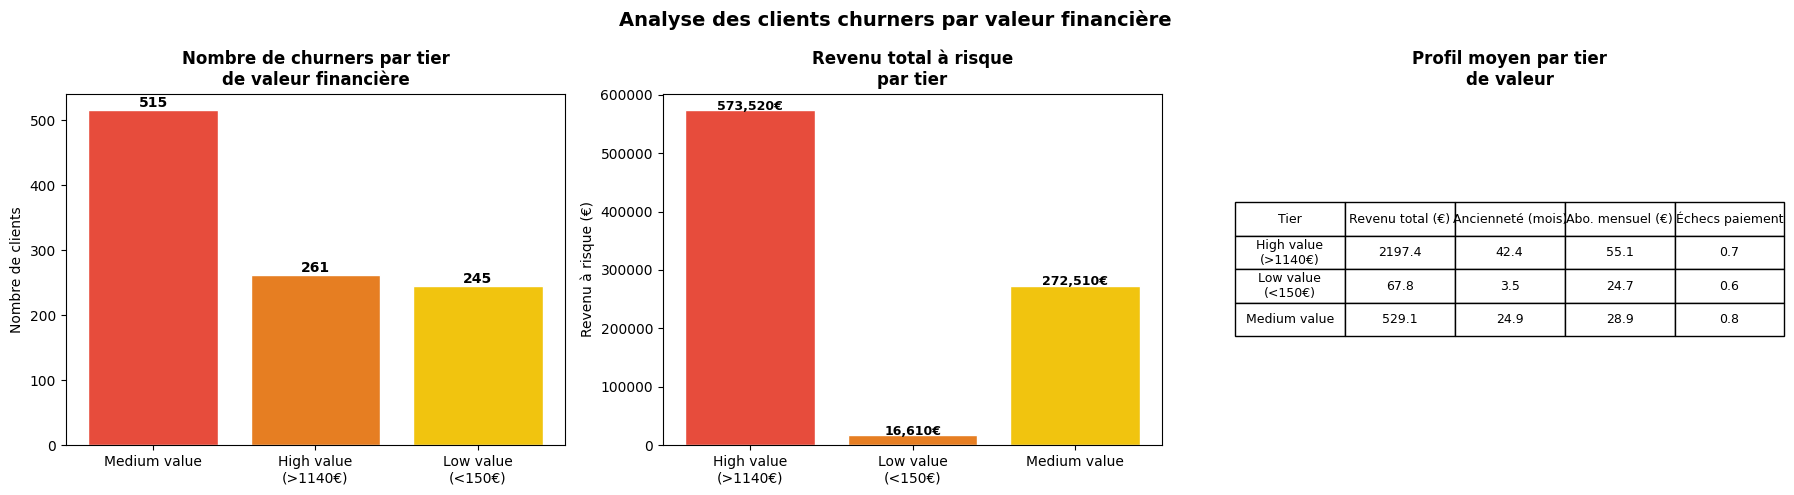


📊 Résumé financier :
   Revenu total à risque       : 862,640€
   Part des High Value churners : 66.5% du risque total
   → Priorité de rétention sur 515 clients pour protéger 573,520€


In [22]:
# ANALYSE DES CLIENTS À FORTE VALEUR FINANCIÈRE

churners = df[df['churn'] == 1].copy()

q75 = churners['revenue_at_risk'].quantile(0.75)
q25 = churners['revenue_at_risk'].quantile(0.25)

def categorize(val):
    if val >= q75:
        return 'High value\n(>' + f'{q75:.0f}€)'
    elif val >= q25:
        return 'Medium value'
    else:
        return 'Low value\n(<' + f'{q25:.0f}€)'

churners['value_tier'] = churners['revenue_at_risk'].apply(categorize)

tier_order = [f'High value\n(>{q75:.0f}€)', 'Medium value', f'Low value\n(<{q25:.0f}€)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphe 1 — Répartition par tier
tier_counts = churners['value_tier'].value_counts()
tier_revenue = churners.groupby('value_tier')['revenue_at_risk'].sum()

colors_tier = ['#e74c3c', '#e67e22', '#f1c40f']
axes[0].bar(tier_counts.index, tier_counts.values, color=colors_tier, edgecolor='white')
axes[0].set_title('Nombre de churners par tier\nde valeur financière', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nombre de clients')
for j, (idx, v) in enumerate(tier_counts.items()):
    axes[0].text(j, v + 5, str(v), ha='center', fontweight='bold')

# Graphe 2 — Revenu total par tier
axes[1].bar(tier_revenue.index, tier_revenue.values, color=colors_tier, edgecolor='white')
axes[1].set_title('Revenu total à risque\npar tier', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Revenu à risque (€)')
for j, (idx, v) in enumerate(tier_revenue.items()):
    axes[1].text(j, v + 1000, f'{v:,.0f}€', ha='center', fontsize=9, fontweight='bold')

# Graphe 3 — Profil moyen par tier
profil_tier = churners.groupby('value_tier')[['total_revenue', 'tenure_months',
                                               'monthly_fee', 'payment_failures']].mean()
profil_tier = profil_tier.round(1)

axes[2].axis('off')
table_data = profil_tier.reset_index().values.tolist()
col_labels = ['Tier', 'Revenu total (€)', 'Ancienneté (mois)', 'Abo. mensuel (€)', 'Échecs paiement']
table = axes[2].table(cellText=table_data,
                       colLabels=col_labels,
                       loc='center',
                       cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 2.2)
axes[2].set_title('Profil moyen par tier\nde valeur', fontsize=12, fontweight='bold')

plt.suptitle('Analyse des clients churners par valeur financière',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé texte
total_risk = churners['revenue_at_risk'].sum()
high_risk = tier_revenue.get(f'High value\n(>{q75:.0f}€)', 0)
print(f"\nRésumé financier :")
print(f"   Revenu total à risque       : {total_risk:,.0f}€")
print(f"   Part des High Value churners : {high_risk/total_risk*100:.1f}% du risque total")
print(f"   → Priorité de rétention sur {tier_counts.iloc[0]} clients pour protéger {high_risk:,.0f}€")

# Synthèse de l'EDA

## Ce qu'on a découvert
1. **Déséquilibre** : 89.8% restent vs 10.2% partent
2. **Nouveaux clients** à risque : tenure_months bas = plus de churn
3. **Signaux forts** : payment_failures, csat_score, support_tickets
4. **Segments à risque** : SME (30.9%), Mobile (30%), hausse prix (30.4%)
5. **Corrélation forte** : monthly_fee ↔ total_revenue (0.71)
6. **Valeurs manquantes** : complaint_type (2045) → "No_Complaint"
7. **Outliers** : conservés car signaux business réels

## Décisions pour le Preprocessing (étape suivante)
1. Supprimer `customer_id` et `city` (inutiles pour la prédiction)
2. Remplir `complaint_type` manquants par "No_Complaint"
3. Encoder les 12 variables catégorielles en chiffres
4. Normaliser les variables numériques (StandardScaler)
5. Gérer le déséquilibre avec `class_weight='balanced'`
6. Séparer Train (80%) / Test (20%) de façon stratifiée